In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
customers=pd.read_csv('Data\olist_customers_dataset.csv')
geolocation=pd.read_csv('Data\olist_geolocation_dataset.csv')
order_items=pd.read_csv('Data\olist_order_items_dataset.csv')
order_payments=pd.read_csv('Data\olist_order_payments_dataset.csv')
order_reviews=pd.read_csv('Data\olist_order_reviews_dataset.csv')
orders=pd.read_csv('Data\olist_orders_dataset.csv')
products=pd.read_csv('Data\olist_products_dataset.csv')
sellers=pd.read_csv('Data\olist_sellers_dataset.csv')
category=pd.read_csv('Data\product_category_name_translation.csv')

In [5]:
print("Orders:",orders.shape)
print("Items:",order_items.shape)
print("Customers:",customers.shape)
print("Products:",products.shape)
print("Category:",category.shape)
print("Customers:",customers.shape)


Orders: (99441, 8)
Items: (112650, 7)
Customers: (99441, 5)
Products: (32951, 9)
Category: (71, 2)
Customers: (99441, 5)


In [6]:
print("=== Orders Nulls ===")
print(orders.isnull().sum())
print("=== Items Nulls ===")
print(order_items.isnull().sum())
print("=== Customers Nulls ===")
print(customers.isnull().sum())
print("=== Products Nulls ===")
print(products.isnull().sum())
print("=== Category Nulls ===")
print(category.isnull().sum())
print("=== Order Payments Nulls ===")
print(order_payments.isnull().sum())
print("=== Order Review Nulls ===")
print(order_reviews.isnull().sum())

=== Orders Nulls ===
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
=== Items Nulls ===
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
=== Customers Nulls ===
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
=== Products Nulls ===
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
produc

In [7]:
order_clean=orders[orders['order_status']=='delivered'].copy()
order_clean.dropna(subset=['order_approved_at','order_delivered_carrier_date','order_delivered_customer_date'],inplace=True)
products=products.fillna({'product_category_name':'Unknown'})
products=products.dropna()
reviews_clean=order_reviews[['order_id','review_score']].copy()
order_clean['order_purchase_timestamp']=pd.to_datetime(order_clean['order_purchase_timestamp'])
order_clean=order_clean.drop_duplicates()
order_items=order_items.drop_duplicates()

print("Orders after cleaning:",order_clean.shape)
print("Products after cleaning:",products.shape)
print("Reviews after cleaning:",reviews_clean.shape)

Orders after cleaning: (96455, 8)
Products after cleaning: (32340, 9)
Reviews after cleaning: (99224, 2)


In [8]:
df=pd.merge(order_clean,order_items,on='order_id',how='inner')
df=pd.merge(df,products[['product_id','product_category_name']],on='product_id',how='left')
df=pd.merge(df,category,on='product_category_name',how='left')
df=pd.merge(df,customers[['customer_id','customer_state']],on='customer_id',how='left')
df=pd.merge(df,reviews_clean,on='order_id',how='left')
df['month']=df['order_purchase_timestamp'].dt.month
df['year']=df['order_purchase_timestamp'].dt.year
df['month_year']=df['order_purchase_timestamp'].dt.to_period('M')

print("Merged dataframe shape:",df.shape)
print("\ncolumns:",df.columns.tolist())

Merged dataframe shape: (110816, 21)

columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_category_name_english', 'customer_state', 'review_score', 'month', 'year', 'month_year']


In [9]:
category_revenue=df.groupby('product_category_name_english')['price'].sum()
category_revenue=category_revenue.sort_values(ascending=False).head(10)

print("=== Q1: Top 10 categories by Revenue ===")
print(category_revenue)

=== Q1: Top 10 categories by Revenue ===
product_category_name_english
health_beauty            1237439.95
watches_gifts            1166968.63
bed_bath_table           1037043.70
sports_leisure            959941.11
computers_accessories     896132.29
furniture_decor           717910.18
housewares                617836.73
cool_stuff                611831.89
auto                      580146.14
toys                      471920.79
Name: price, dtype: float64


In [10]:
monthly_sales=df.groupby('month_year')['order_id'].nunique()
monthly_sales=monthly_sales.sort_values(ascending=False)

print("=== Q2: Peak Sales Month ===")
print(monthly_sales)

=== Q2: Peak Sales Month ===
month_year
2017-11    7288
2018-01    7069
2018-03    7003
2018-04    6798
2018-05    6749
2018-02    6555
2018-08    6351
2018-07    6156
2018-06    6096
2017-12    5513
2017-10    4478
2017-08    4193
2017-09    4149
2017-07    3872
2017-05    3545
2017-06    3135
2017-03    2546
2017-04    2303
2017-02    1641
2017-01     748
2016-10     265
2016-12       1
2016-09       1
Freq: M, Name: order_id, dtype: int64


In [11]:
region_sales=df.groupby('customer_state')['price'].sum()
region_sales=region_sales.sort_values(ascending=False).head(10)

print("=== Q3: Top 10  Region by Revenue ===")
print(region_sales)

=== Q3: Top 10  Region by Revenue ===
customer_state
SP    5091551.65
RJ    1766078.98
MG    1558427.48
RS     731728.81
PR     668891.26
SC     508578.90
BA     495416.93
DF     298492.74
GO     285780.24
ES     269230.52
Name: price, dtype: float64


In [12]:
avg_order_value=df.groupby('month_year')['price'].mean()

print("=== Q4: Average Order Value by Month ===")
print(avg_order_value)

=== Q4: Average Order Value by Month ===
month_year
2016-09     44.990000
2016-10    127.608202
2016-12     10.900000
2017-01    122.003796
2017-02    126.023093
2017-03    123.711090
2017-04    132.405751
2017-05    121.680613
2017-06    120.711595
2017-07    108.663170
2017-08    115.299322
2017-09    127.792694
2017-10    123.941876
2017-11    116.574817
2017-12    117.289374
2018-01    114.988494
2018-02    109.717819
2018-03    118.666166
2018-04    124.493418
2018-05    125.088334
2018-06    122.119478
2018-07    124.516684
2018-08    117.392324
Freq: M, Name: price, dtype: float64


In [13]:
review_dist=df['review_score'].value_counts().sort_index()

print("=== Q5: Review Score Distribution ===")
print(review_dist)

print("\n=== Percentage ===")
print(round(review_dist/review_dist.sum()*100,2))

=== Q5: Review Score Distribution ===
review_score
1.0    12574
2.0     3699
3.0     9241
4.0    21179
5.0    63296
Name: count, dtype: int64

=== Percentage ===
review_score
1.0    11.43
2.0     3.36
3.0     8.40
4.0    19.26
5.0    57.55
Name: count, dtype: float64


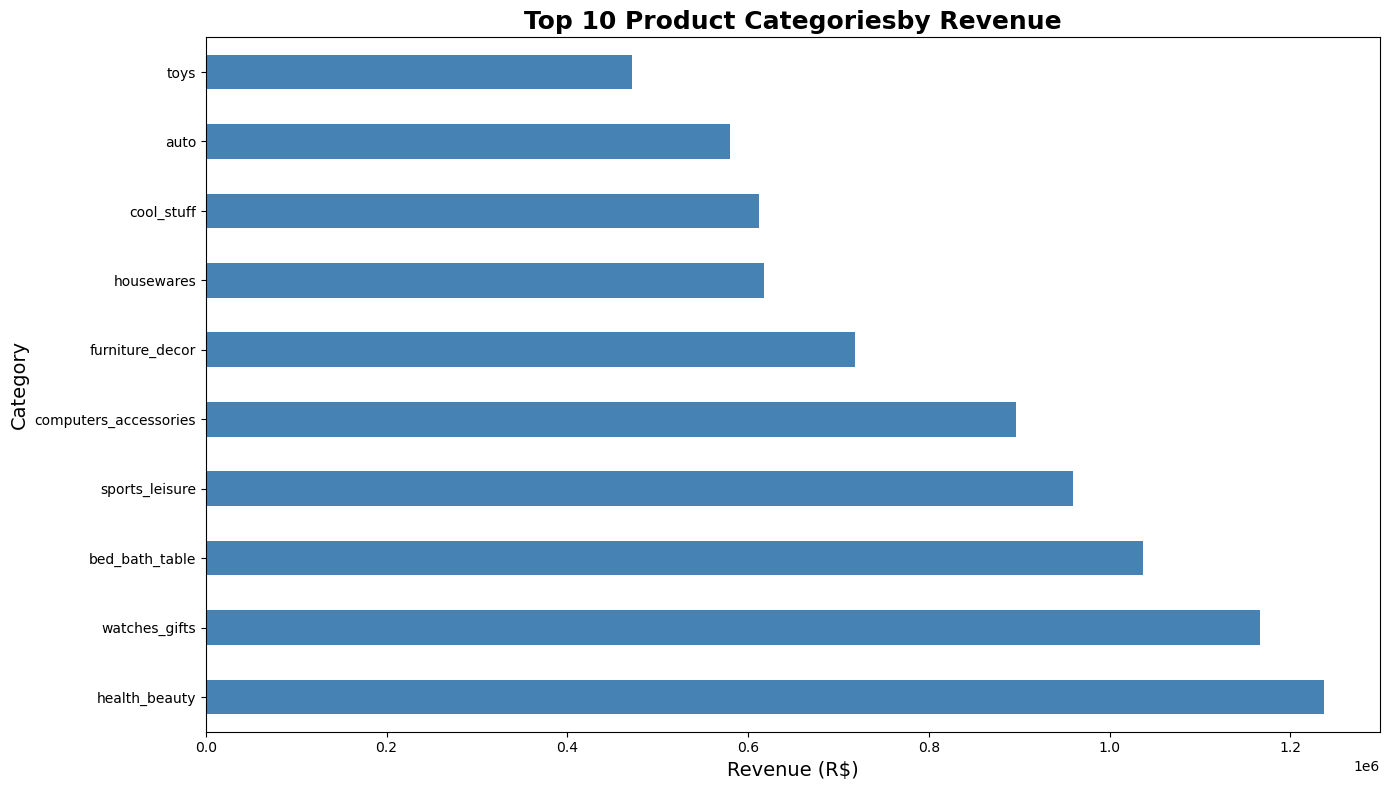

Chart1 saved!


In [14]:
plt.figure(figsize=(14,8))
category_revenue.plot(kind='barh',color='steelblue')
plt.title('Top 10 Product Categoriesby Revenue',fontsize=18,fontweight='bold')
plt.xlabel('Revenue (R$)',fontsize=14)
plt.ylabel('Category',fontsize=14)
plt.tight_layout()
plt.savefig('chart1_category_revenue.png',dpi=150)
plt.show()
print("Chart1 saved!")

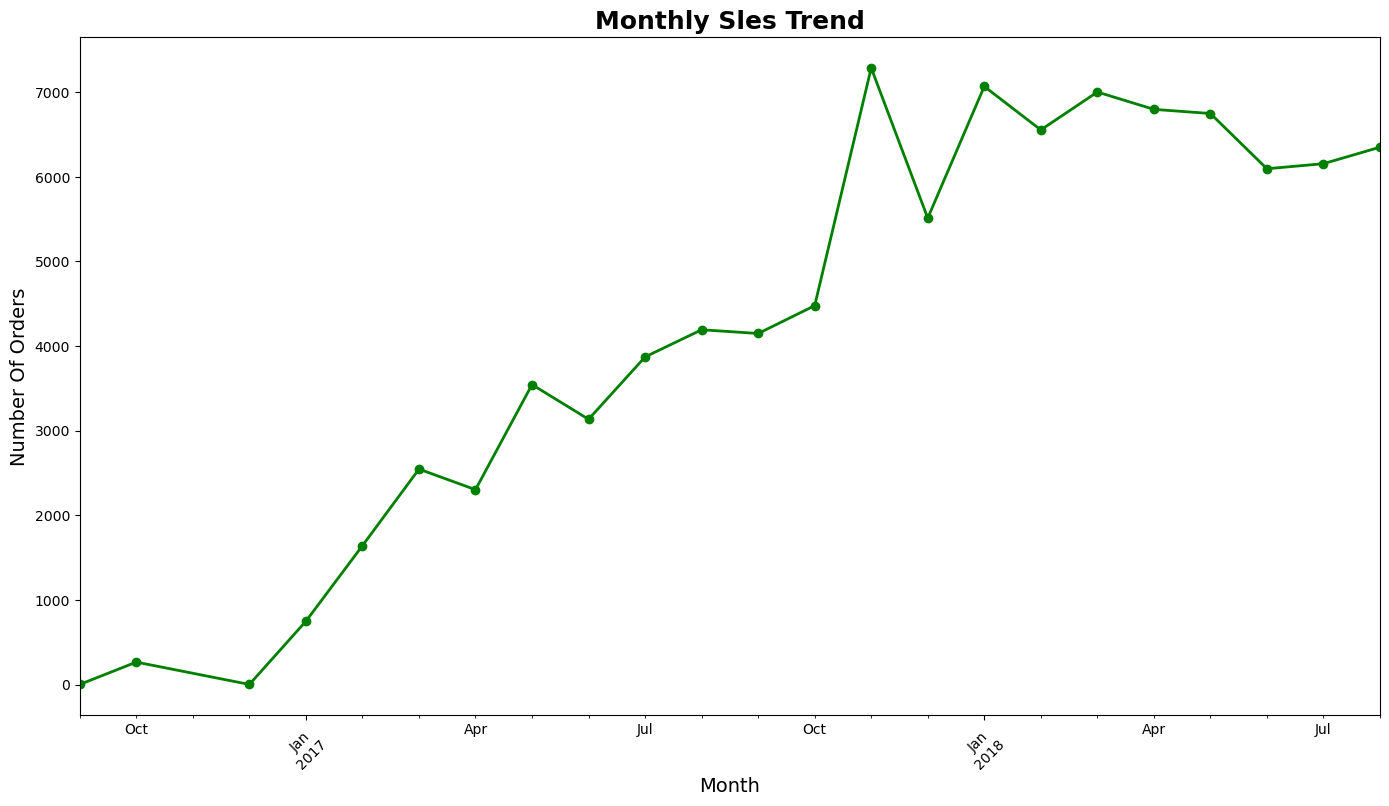

Chart2 saved!


In [15]:
plt.figure(figsize=(14,8))
monthly_sales.sort_index().plot(kind='line',marker='o',color='green',linewidth=2)
plt.title('Monthly Sles Trend',fontsize=18,fontweight='bold')
plt.xlabel('Month',fontsize=14)
plt.ylabel('Number Of Orders',fontsize=14)
plt.tight_layout()
plt.savefig('chart2_monthly_trend.png',dpi=150)
plt.xticks(rotation=45)
plt.show()
print("Chart2 saved!")

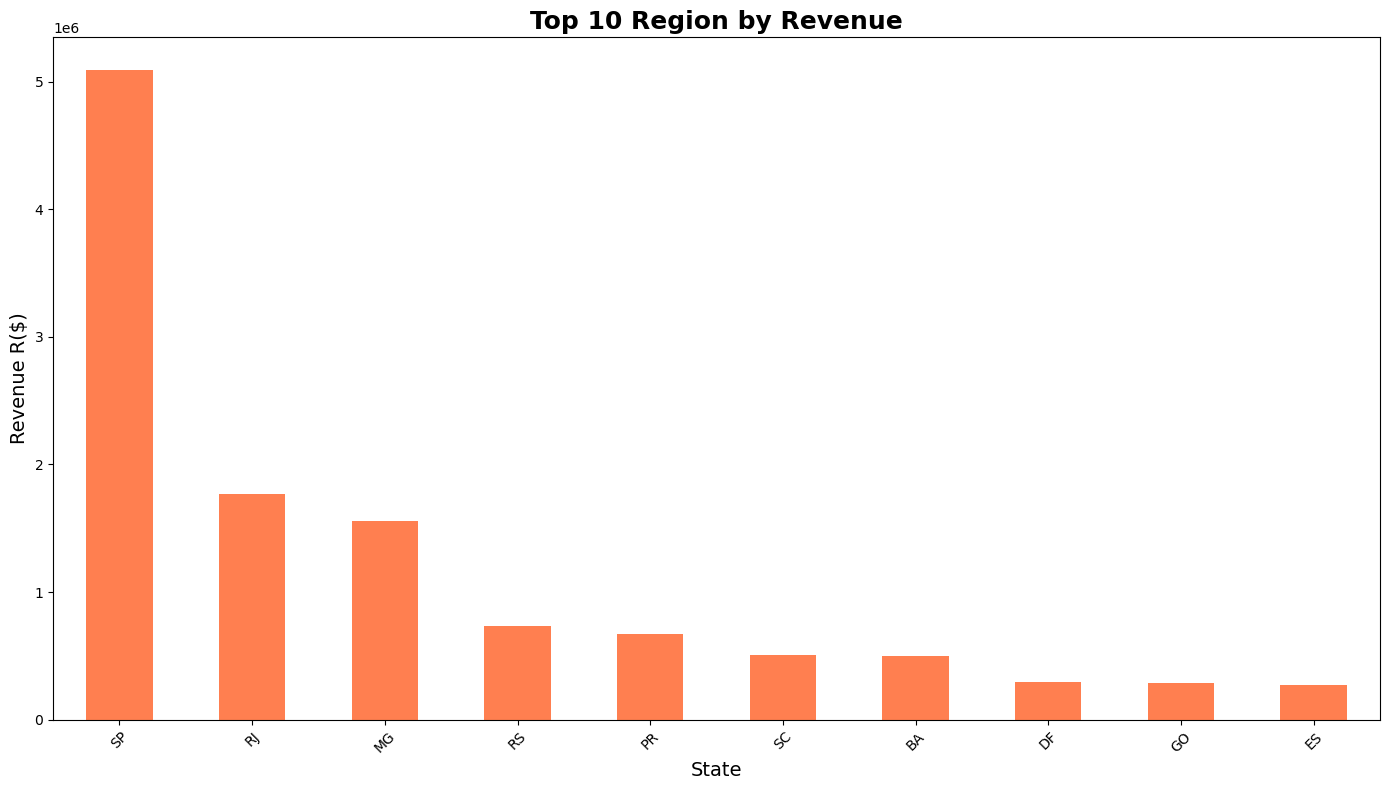

Chart3 saved!


In [16]:
plt.figure(figsize=(14,8))
region_sales.plot(kind='bar',color='coral')
plt.title('Top 10 Region by Revenue',fontsize=18,fontweight='bold')
plt.xlabel('State',fontsize=14)
plt.ylabel('Revenue R($)',fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart3_regional_sales.png',dpi=150)
plt.show()
print("Chart3 saved!")

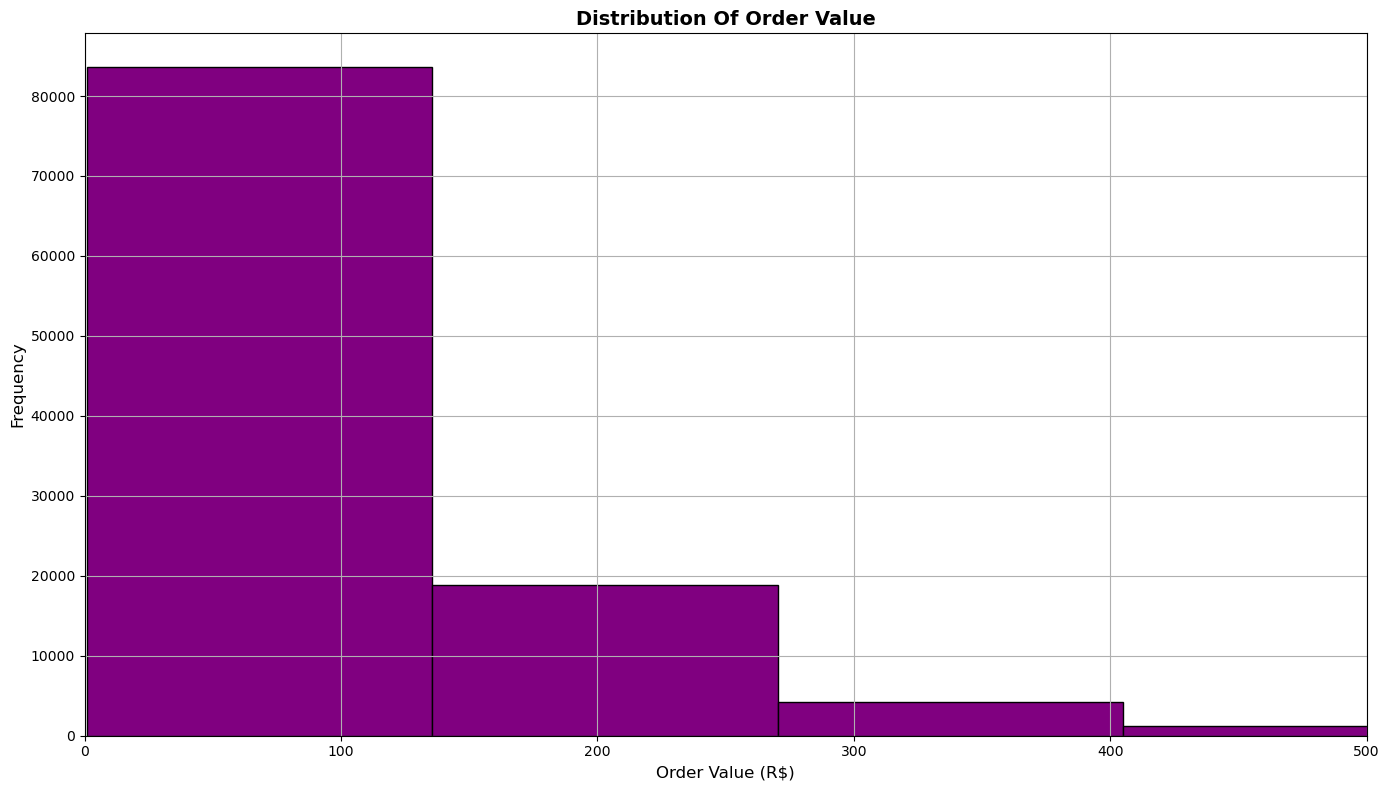

Chart4 saved!


In [17]:
plt.figure(figsize=(14,8))
df['price'].hist(bins=50,color='purple',edgecolor='black')
plt.title('Distribution Of Order Value',fontsize=14,fontweight='bold')
plt.xlabel('Order Value (R$)',fontsize=12)
plt.ylabel('Frequency',fontsize=12)
plt.xlim(0,500)
plt.tight_layout()
plt.savefig('chart4_order_values.png',dpi=150)
plt.show()
print("Chart4 saved!")

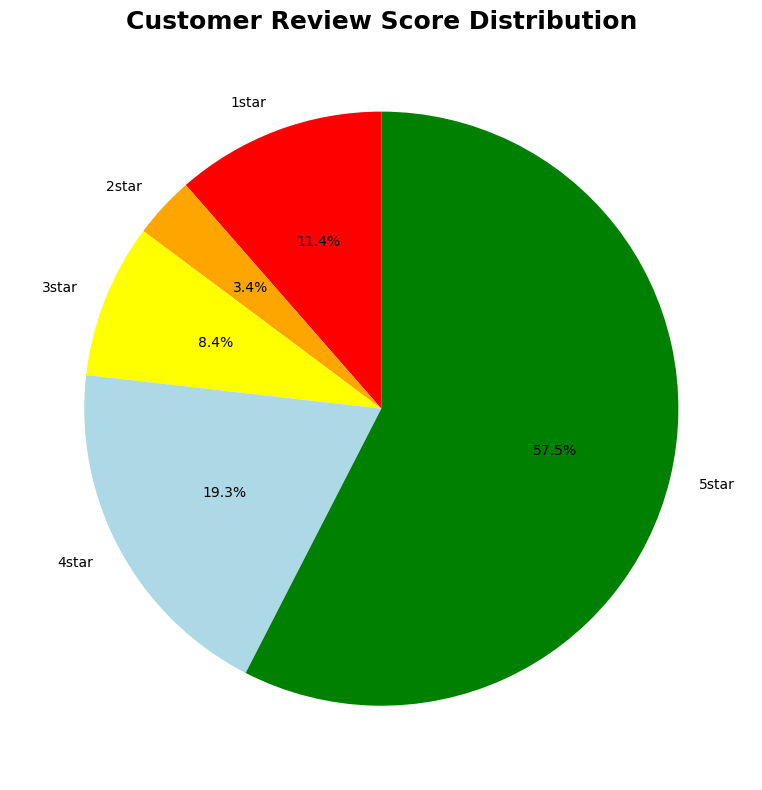

Chart5 saved!


In [18]:
plt.figure(figsize=(8,8))
review_dist.plot(kind='pie',autopct='%1.1f%%',colors=['red','orange','yellow','lightblue','green'],
                labels=['1star','2star','3star','4star','5star'],startangle=90)
plt.title('Customer Review Score Distribution',fontsize=18,fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.savefig('chart5_review_scores.png',dpi=150)
plt.show()
print("Chart5 saved!")

In [19]:
heatmap_data=df.groupby(['month','product_category_name_english'])['price'].sum().unstack()
heatmap_data=heatmap_data[category_revenue.index]
print(heatmap_data)

product_category_name_english  health_beauty  watches_gifts  bed_bath_table  \
month                                                                         
1                                   84059.22       81607.76        79781.02   
2                                  107553.12       71717.70        77795.74   
3                                  110171.01      120580.43        94854.87   
4                                  113234.78      112604.15        95993.44   
5                                  141423.23      156215.26       104918.16   
6                                  138602.49      112365.20       106037.19   
7                                  138156.52      128644.21       118960.92   
8                                  169116.52      105938.01       118574.44   
9                                   51279.03       44805.95        52450.09   
10                                  44412.20       67585.70        47865.63   
11                                  78333.39       9

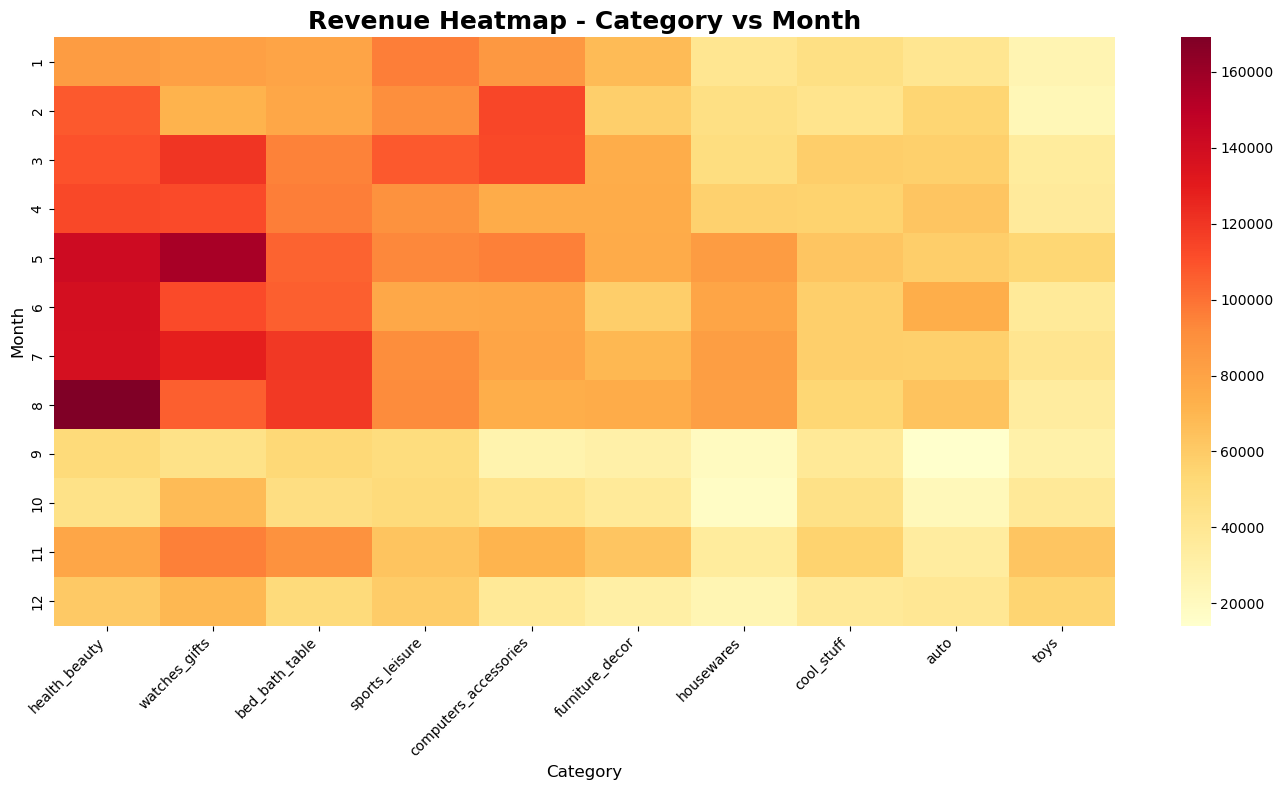

Chart6 saved!


In [20]:
plt.figure(figsize=(14,8))
sns.heatmap(heatmap_data,cmap='YlOrRd',fmt='.0f',annot=False)
plt.title('Revenue Heatmap - Category vs Month',fontsize=18,fontweight='bold')
plt.xlabel('Category',fontsize=12)
plt.ylabel('Month',fontsize=12)
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.savefig('chart6_heatmap.png',dpi=150)
plt.show()
print("Chart6 saved!")

# Business Insights Report
## E-Commerce Sales Analysis — Olist Dataset

---

### Insight 1 — Health & Beauty Dominates Revenue
**Finding:** As seen in the Revenue by Category bar chart,
Health & Beauty is the top performing category with
R$ 1,237,439 in total revenue — 6% more than
Watches & Gifts in second place.

**Recommendation:** Increase marketing budget and stock
availability for Health & Beauty products to maintain
and grow this lead.

---

### Insight 2 — November 2017 is the Peak Sales Month
**Finding:** The monthly sales trend line chart shows a
sharp spike in November 2017 with 7,288 orders —
likely due to Black Friday promotions.

**Recommendation:** Plan promotional campaigns and ensure
extra inventory 2 weeks before November every year
to handle the demand surge.

---

### Insight 3 — São Paulo Dominates Regional Sales
**Finding:** The regional bar chart shows São Paulo (SP)
generates R$ 5,091,551 — nearly 3x more than
Rio de Janeiro (RJ) in second place.

**Recommendation:** Expand logistics and delivery
partnerships in northern and western states to tap
into underserved markets and grow revenue.

---

### Insight 4 — Average Order Value is Stable
**Finding:** The order value histogram and monthly trend
show average order value is consistently between
R$ 108 — R$ 132, with April 2017 being highest at R$ 132.

**Recommendation:** Introduce bundle offers and minimum
order discounts to push average order value above R$ 150
and increase revenue per customer.

---

### Insight 5 — Customer Satisfaction is Strong
**Finding:** The review score pie chart shows 76.81% of
customers gave 4 or 5 stars. However, 11.43% gave
1 star which needs immediate attention.

**Recommendation:** Investigate 1-star reviews for common
complaints such as delayed delivery or damaged products
and address them to improve customer retention.

---

###  Most Surprising Finding
The most surprising finding was the dominance of São Paulo
in regional sales — it alone contributes nearly 3x more
revenue than any other state. This shows that the business
is heavily concentrated in one region, which is both a
strength and a risk if that market faces any disruption.

In [23]:
df.to_csv('powerbi_dat.csv',index=False)
category_revenue.reset_index().to_csv('category_revenue.csv',index=False)
monthly_sales.reset_index().to_csv('monthly_sales.csv',index=False)
region_sales.reset_index().to_csv('region_sales.csv',index=False)
print("All files exported successfully")

All files exported successfully
